# Action-Angle Coordinates: Reverse Transformations (actionAngleTorus)

The `actionAngleTorus` class performs the **reverse** transformation: given
actions and angles, it computes phase-space coordinates
$(\mathbf{x}, \mathbf{v})$. It uses an interface to the
[TorusMapper](https://github.com/PaulMcMillan-Astro/Torus) code
(McMillan & Binney 2008).

This is useful for:
- Setting up initial conditions with specific actions
- Computing orbital tori
- Mapping the orbital building blocks of galaxies

Currently, this is limited to axisymmetric potentials.

For the forward transformation (coordinates to actions), see the
[Introduction](introduction.ipynb), the [Staeckel Approximation](staeckel.ipynb),
or the [Isochrone Approximation](isochroneapprox.ipynb).

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.potential import MWPotential2014
from galpy.orbit import Orbit

## Setup

The `actionAngleTorus` class requires a C extension that may not be available
in all installations. We wrap the setup in a try/except block:

In [2]:
from galpy.actionAngle import actionAngleTorus

try:
    aAT = actionAngleTorus(pot=MWPotential2014)
    _has_torus = True
except RuntimeError:
    print("actionAngleTorus C extension not available; skipping torus examples")
    _has_torus = False

## Computing frequencies

Given a set of actions $(J_R, L_z, J_z)$, we first compute the frequencies
using the `Freqs` method. This returns
$(\Omega_R, \Omega_\phi, \Omega_z, \mathrm{err})$, where the last entry
is the exit code of the TorusMapper (printed as a warning when non-zero):

In [3]:
if _has_torus:
    jr_val, lz_val, jz_val = 0.1, 1.1, 0.2
    Om = aAT.Freqs(jr_val, lz_val, jz_val)
    print(f"Omega_R = {Om[0]:.6f}, Omega_phi = {Om[1]:.6f}, Omega_z = {Om[2]:.6f}")
else:
    print("Skipped: actionAngleTorus not available")

Omega_R = 0.809430, Omega_phi = 0.584330, Omega_z = 0.654568


## Forward transform: actions+angles to phase-space coordinates

The basic usage is `aAT(jr, lz, jz, angler, anglephi, anglez)`, which
returns `[R, vR, vT, z, vz, phi]`.

### Computing an orbit from action-angle coordinates

We can compute a set of angles that fall along an orbit as
$\boldsymbol{\theta}(t) = \boldsymbol{\theta}_0 + \boldsymbol{\Omega} t$:

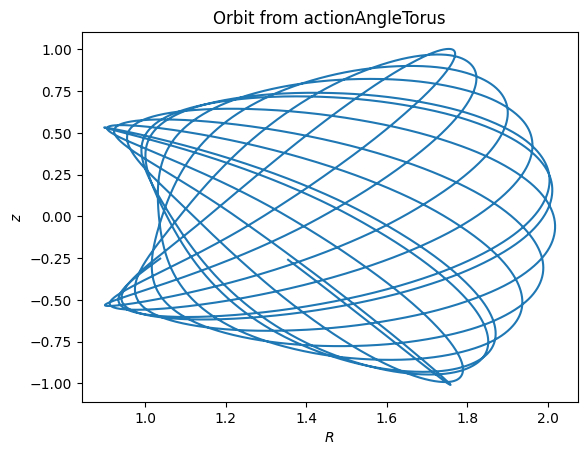

In [4]:
if _has_torus:
    jr_val, lz_val, jz_val = 0.1, 1.1, 0.2
    times = numpy.linspace(0.0, 100.0, 10001)
    init_angle = numpy.array([1.0, 2.0, 3.0])
    angles = (
        numpy.tile(init_angle, (len(times), 1)) + Om[:3] * numpy.tile(times, (3, 1)).T
    )

    RvR, _, _, _, _ = aAT.xvFreqs(
        jr_val, lz_val, jz_val, angles[:, 0], angles[:, 1], angles[:, 2]
    )

    plt.plot(RvR[:, 0], RvR[:, 3])
    plt.xlabel(r"$R$")
    plt.ylabel(r"$z$")
    plt.title("Orbit from actionAngleTorus")
else:
    print("Skipped: actionAngleTorus not available")

### Comparison with direct orbit integration

We can compare this to a numerically integrated orbit starting from the
same initial conditions:

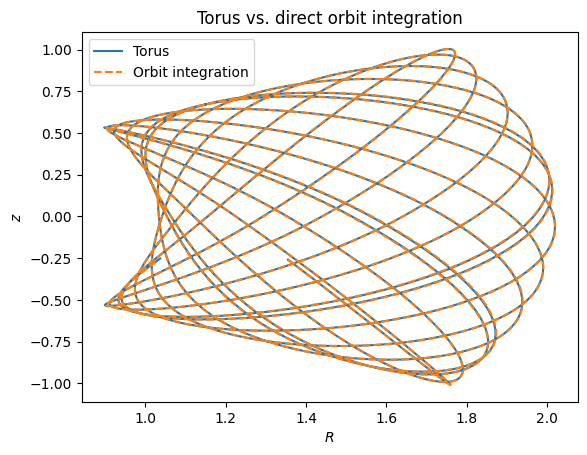

In [5]:
if _has_torus:
    orb = Orbit(RvR[0])
    orb.integrate(times, MWPotential2014)

    plt.plot(RvR[:, 0], RvR[:, 3], label="Torus")
    plt.plot(orb.R(times), orb.z(times), "--", label="Orbit integration")
    plt.xlabel(r"$R$")
    plt.ylabel(r"$z$")
    plt.legend()
    plt.title("Torus vs. direct orbit integration")
else:
    print("Skipped: actionAngleTorus not available")

The two orbits are exactly the same.

## The xvFreqs method

The `xvFreqs` method returns both phase-space coordinates and frequencies.
The frequency is always computed and returned because it can be obtained
at zero cost. The return value is
`(RvR, OR, Op, Oz, err)` where `RvR` has shape `(ntimes, 6)` with
columns `(R, vR, vT, z, vz, phi)`:

In [6]:
if _has_torus:
    angler = numpy.linspace(0.0, 2.0 * numpy.pi, 101)
    anglephi = numpy.zeros(101)
    anglez = numpy.zeros(101)

    result = aAT.xvFreqs(jr_val, lz_val, jz_val, angler, anglephi, anglez)
    RvR_slice = result[0]
    OR, Op, Oz = result[1], result[2], result[3]

    print(f"Omega_R = {OR:.6f}, Omega_phi = {Op:.6f}, Omega_z = {Oz:.6f}")
else:
    print("Skipped: actionAngleTorus not available")

Omega_R = 0.809430, Omega_phi = 0.584330, Omega_z = 0.654568


## Orbital torus cross-section

By varying one angle while holding the others fixed, we can visualize
a cross-section of the orbital torus:

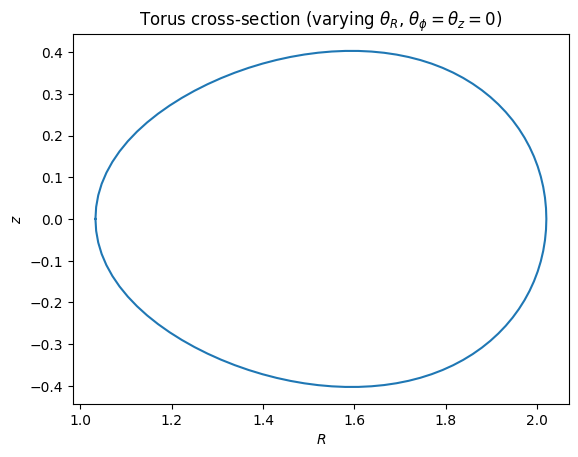

In [7]:
if _has_torus:
    plt.plot(RvR_slice[:, 0], RvR_slice[:, 3])
    plt.xlabel(r"$R$")
    plt.ylabel(r"$z$")
    plt.title(r"Torus cross-section (varying $\theta_R$, $\theta_\phi = \theta_z = 0$)")
else:
    print("Skipped: actionAngleTorus not available")

## Mapping a full torus

We do not have to follow the path of an orbit to map the entire orbital
torus. By sampling random angles uniformly in $[0, 2\pi]$, we can directly
visualize where the orbit spends most of its time:

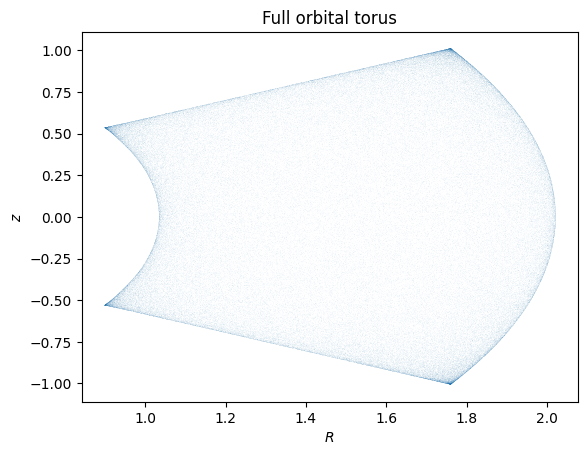

In [8]:
if _has_torus:
    nangles = 200001
    angler_rand = numpy.random.uniform(size=nangles) * 2.0 * numpy.pi
    anglep_rand = numpy.random.uniform(size=nangles) * 2.0 * numpy.pi
    anglez_rand = numpy.random.uniform(size=nangles) * 2.0 * numpy.pi

    RvR_torus, _, _, _, _ = aAT.xvFreqs(
        jr_val, lz_val, jz_val, angler_rand, anglep_rand, anglez_rand
    )

    plt.plot(RvR_torus[:, 0], RvR_torus[:, 3], ",", alpha=0.02)
    plt.xlabel(r"$R$")
    plt.ylabel(r"$z$")
    plt.title("Full orbital torus")
else:
    print("Skipped: actionAngleTorus not available")

This directly shows where the orbit spends most of its time.

`actionAngleTorus` also has additional methods for computing Hessians
and Jacobians of the transformation between action-angle and configuration
space coordinates. See the action-angle API documentation for details.